In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

In [3]:
dataset = pd.read_csv('heart_disease.csv')
print(dataset.head())

    Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   
1                  Yes      Yes  25.221799                  No  ...   
2                   No       No  29.855447                  No  ...   
3                  Yes       No  24.130477                 Yes  ...   
4                  Yes      Yes  20.486289                 Yes  ...   

  High LDL Cholesterol Alcohol Consumption Stress Level Sleep Hours  \
0                   No           

In [5]:
# Check class imbalance in target variable
print("\n=== CLASS IMBALANCE ANALYSIS ===")
target_column = dataset.columns[-1]  # Assuming last column is target
print(f"Target variable: {target_column}")
print("\nClass distribution:")
class_dist = dataset[target_column].value_counts()
print(class_dist)
print("\nClass distribution (%):")
print((class_dist / len(dataset) * 100).round(2))
print("\n⚠️ WARNING: Severe class imbalance detected!")
print("A model predicting all 'No' would get 80% accuracy but be useless.")
print("Solution: Using class_weight='balanced' to penalize misclassification of minority class.")


=== CLASS IMBALANCE ANALYSIS ===
Target variable: Heart Disease Status

Class distribution:
Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Class distribution (%):
Heart Disease Status
No     80.0
Yes    20.0
Name: count, dtype: float64

⚠️ WARNING: Severe class imbalance detected!
A model predicting all 'No' would get 80% accuracy but be useless.
Solution: Using class_weight='balanced' to penalize misclassification of minority class.


In [6]:
# Check for and drop duplicates
print(f"Initial dataset shape: {dataset.shape}")
print(f"Duplicate rows: {dataset.duplicated().sum()}")

dataset = dataset.drop_duplicates()
print(f"Dataset shape after dropping duplicates: {dataset.shape}")
print(f"Rows removed: {dataset.shape[0] - dataset.shape[0]}")
dataset = dataset.reset_index(drop=True)

Initial dataset shape: (10000, 21)
Duplicate rows: 0
Dataset shape after dropping duplicates: (10000, 21)
Rows removed: 0


In [7]:
# Handle Missing Values
print("\n=== HANDLING MISSING VALUES ===\n")

# Show missing values summary
print("Missing values before imputation:")
missing_vals = dataset.isnull().sum()
missing_pct = (missing_vals / len(dataset) * 100).round(2)
missing_df = pd.DataFrame({'Column': missing_vals.index, 'Missing_Count': missing_vals.values, 'Missing_%': missing_pct.values})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df.to_string(index=False))

# Identify numerical and categorical columns
numerical_cols = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = dataset.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Special handling for Alcohol Consumption (if exists)
alcohol_col = 'Alcohol Consumption' if 'Alcohol Consumption' in dataset.columns else None

if alcohol_col:
    print(f"\n📌 Special handling for '{alcohol_col}':")
    print(f"   Missing: {dataset[alcohol_col].isnull().sum()} ({(dataset[alcohol_col].isnull().sum()/len(dataset)*100):.1f}%)")
    print(f"   → Filling with 'Unknown' category (not guessing)")
    dataset[alcohol_col] = dataset[alcohol_col].fillna('Unknown')

# Fill missing values in other columns
for col in numerical_cols:
    if dataset[col].isnull().sum() > 0 and col != target_column:
        median_val = dataset[col].median()
        dataset[col] = dataset[col].fillna(median_val)
        print(f"   Filled {col} (numerical) with median: {median_val:.2f}")

for col in categorical_cols:
    if dataset[col].isnull().sum() > 0 and col != target_column:
        mode_val = dataset[col].mode()[0]
        dataset[col] = dataset[col].fillna(mode_val)
        print(f"   Filled {col} (categorical) with mode: {mode_val}")

# Verify no missing values remain
print(f"\n✅ Missing values after imputation: {dataset.isnull().sum().sum()}")
print("Data cleaning complete!")


=== HANDLING MISSING VALUES ===

Missing values before imputation:
              Column  Missing_Count  Missing_%
 Alcohol Consumption           2586      25.86
   Cholesterol Level             30       0.30
            Diabetes             30       0.30
   Sugar Consumption             30       0.30
                 Age             29       0.29
           CRP Level             26       0.26
  Triglyceride Level             26       0.26
 High Blood Pressure             26       0.26
High LDL Cholesterol             26       0.26
 Low HDL Cholesterol             25       0.25
         Sleep Hours             25       0.25
     Exercise Habits             25       0.25
             Smoking             25       0.25
        Stress Level             22       0.22
 Fasting Blood Sugar             22       0.22
                 BMI             22       0.22
Family Heart Disease             21       0.21
  Homocysteine Level             20       0.20
      Blood Pressure             19    

In [9]:
# 3. Encode Categorical Columns
print("\n=== ENCODING CATEGORICAL COLUMNS ===")

# Binary Yes/No columns -> Label Encode (1/0)
binary_cols = [
    'Smoking', 
    'Family Heart Disease', 
    'Diabetes', 
    'High Blood Pressure', 
    'Low HDL Cholesterol', 
    'High LDL Cholesterol'
]
for col in binary_cols:
    dataset[col] = dataset[col].map({'Yes': 1, 'No': 0})
    print(f"Mapped binary column '{col}': Yes -> 1, No -> 0")

# Gender -> Label Encode (Male=1, Female=0)
dataset['Gender'] = dataset['Gender'].map({'Male': 1, 'Female': 0})
print("Mapped column 'Gender': Male -> 1, Female -> 0")

# Ordered Low/Medium/High columns -> Ordinal Encode (Low=0, Medium=1, High=2)
ordered_cols = ['Exercise Habits', 'Stress Level', 'Sugar Consumption']
ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2}
for col in ordered_cols:
    dataset[col] = dataset[col].map(ordinal_map)
    print(f"Mapped ordered column '{col}': Low -> 0, Medium -> 1, High -> 2")

# Special handling for Alcohol Consumption (handling the 'Unknown' category introduced during imputation)
alcohol_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Unknown': -1}
dataset['Alcohol Consumption'] = dataset['Alcohol Consumption'].map(alcohol_map)
print("Mapped ordered column 'Alcohol Consumption' (with 'Unknown' -> -1): Low -> 0, Medium -> 1, High -> 2, Unknown -> -1")

# Verify the changes
print("\nEncoded dataset head:")
print(dataset[binary_cols + ['Gender', 'Exercise Habits', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']].head())


=== ENCODING CATEGORICAL COLUMNS ===
Mapped binary column 'Smoking': Yes -> 1, No -> 0
Mapped binary column 'Family Heart Disease': Yes -> 1, No -> 0
Mapped binary column 'Diabetes': Yes -> 1, No -> 0
Mapped binary column 'High Blood Pressure': Yes -> 1, No -> 0
Mapped binary column 'Low HDL Cholesterol': Yes -> 1, No -> 0
Mapped binary column 'High LDL Cholesterol': Yes -> 1, No -> 0
Mapped column 'Gender': Male -> 1, Female -> 0
Mapped ordered column 'Exercise Habits': Low -> 0, Medium -> 1, High -> 2
Mapped ordered column 'Stress Level': Low -> 0, Medium -> 1, High -> 2
Mapped ordered column 'Sugar Consumption': Low -> 0, Medium -> 1, High -> 2
Mapped ordered column 'Alcohol Consumption' (with 'Unknown' -> -1): Low -> 0, Medium -> 1, High -> 2, Unknown -> -1

Encoded dataset head:
   Smoking  Family Heart Disease  Diabetes  High Blood Pressure  \
0        1                     1         0                    1   
1        0                     1         1                    0   
2  

In [11]:
# 4. Encode Target Column
print("\n=== ENCODING TARGET COLUMN ===")

dataset['Heart Disease Status'] = dataset['Heart Disease Status'].map({'Yes': 1, 'No': 0})
print("Mapped target column 'Heart Disease Status': Yes -> 1, No -> 0")

# Verify the changes
print("\nTarget column value counts after encoding:")
print(dataset['Heart Disease Status'].value_counts())


=== ENCODING TARGET COLUMN ===
Mapped target column 'Heart Disease Status': Yes -> 1, No -> 0

Target column value counts after encoding:
Heart Disease Status
0    8000
1    2000
Name: count, dtype: int64


In [12]:
# 5. Scale Numerical Features
print("\n=== SCALING NUMERICAL FEATURES ===")

numerical_cols = [
    'Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 
    'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 
    'CRP Level', 'Homocysteine Level'
]

# Initialize and apply StandardScaler
scaler = StandardScaler()
dataset[numerical_cols] = scaler.fit_transform(dataset[numerical_cols])

print(f"Applied StandardScaler to: {numerical_cols}")

# Verify the changes (means should be close to 0 and standard deviations close to 1)
print("\nScaled numerical features head:")
print(dataset[numerical_cols].head())


=== SCALING NUMERICAL FEATURES ===
Applied StandardScaler to: ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

Scaled numerical features head:
        Age  Blood Pressure  Cholesterol Level       BMI  Sleep Hours  \
0  0.369061        0.184661          -1.618712 -0.648537     0.366591   
1  1.084657       -0.214077           1.392213 -0.611996     1.001005   
2 -0.181398       -1.353328          -0.216679  0.123523    -1.456907   
3 -0.952040       -1.581178           1.553102 -0.785226    -0.994883   
4  0.589244        0.925175           0.380910 -1.363683     0.022624   

   Triglyceride Level  Fasting Blood Sugar  CRP Level  Homocysteine Level  
0            1.049660            -0.006024   1.268241           -0.015959  
1           -1.354031             1.564643   0.434477            1.584367  
2            1.636206            -1.194636   1.208400           -0.283696  
3           

In [13]:
dataset.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,0.369061,1,0.184661,-1.618712,2,1,1,0,-0.648537,1,...,0,2,1,0.366591,1,1.049660,-0.006024,1.268241,-0.015959,0
1,1.084657,0,-0.214077,1.392213,2,0,1,1,-0.611996,0,...,0,1,2,1.001005,1,-1.354031,1.564643,0.434477,1.584367,0
2,-0.181398,1,-1.353328,-0.216679,0,0,0,0,0.123523,0,...,1,0,0,-1.456907,0,1.636206,-1.194636,1.208400,-0.283696,0
3,-0.952040,0,-1.581178,1.553102,2,1,1,0,-0.785226,1,...,1,0,2,-0.994883,2,0.486115,-1.109735,1.162067,-1.503680,0
4,0.589244,1,0.925175,0.380910,0,1,1,1,-1.363683,1,...,0,0,2,0.022624,2,0.141087,1.437292,0.671158,-0.996158,0


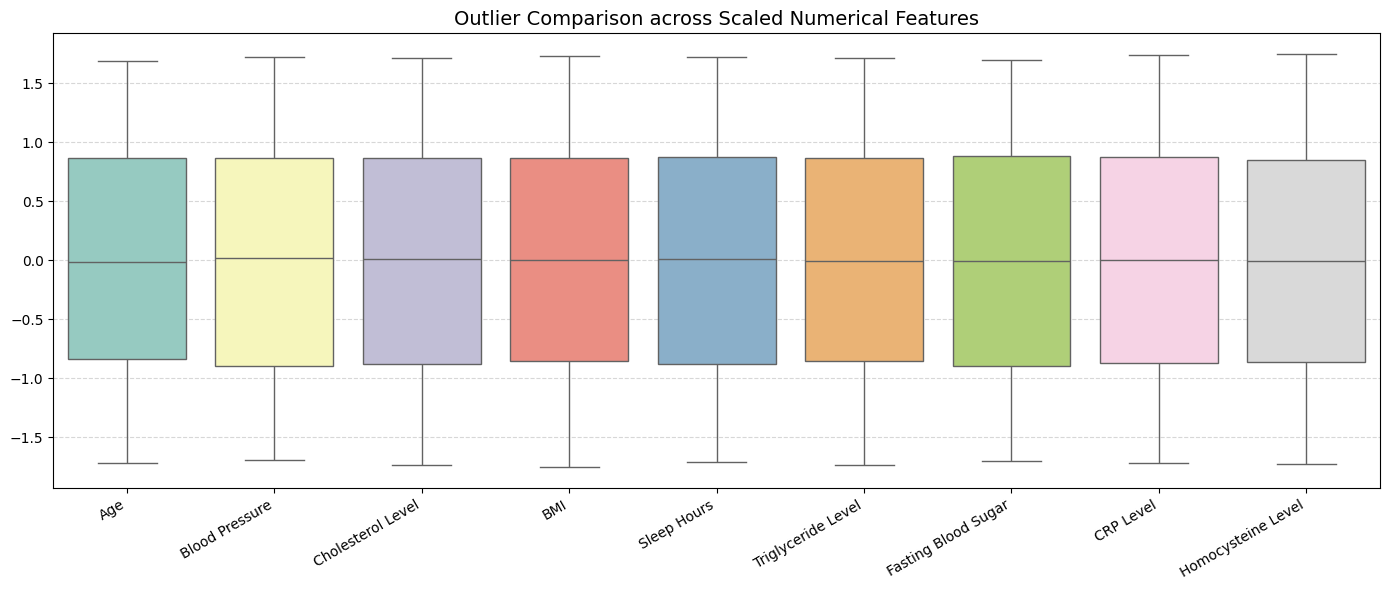

In [14]:
# Visualize Outliers - Combined Scaled Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=dataset[numerical_cols], palette='Set3')
plt.title('Outlier Comparison across Scaled Numerical Features', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


=== GENERATING CORRELATION HEATMAP ===


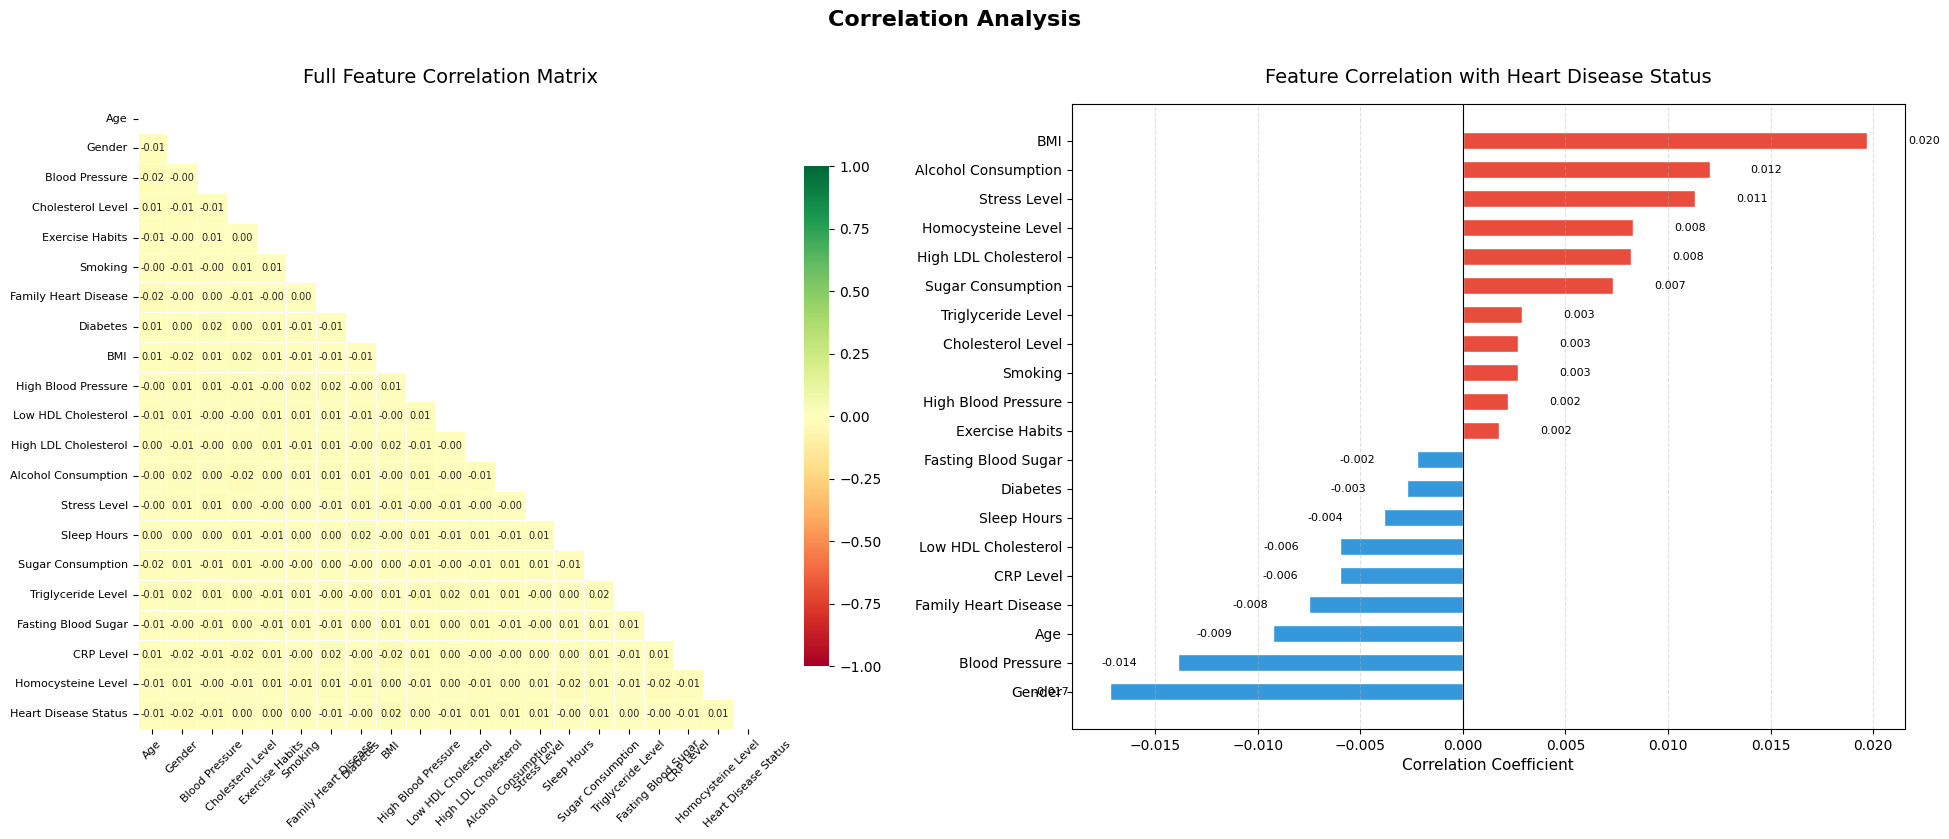


Top 5 features POSITIVELY correlated with Heart Disease:
BMI                     0.019682
Alcohol Consumption     0.012021
Stress Level            0.011332
Homocysteine Level      0.008302
High LDL Cholesterol    0.008201

Top 5 features NEGATIVELY correlated with Heart Disease:
CRP Level              -0.006009
Family Heart Disease   -0.007500
Age                    -0.009231
Blood Pressure         -0.013876
Gender                 -0.017200


In [16]:
# Correlation Heatmap
print("\n=== GENERATING CORRELATION HEATMAP ===")

corr_matrix = dataset.corr()

# Focus on correlation with target only (cleaner and more useful)
target_corr = corr_matrix['Heart Disease Status'].drop('Heart Disease Status').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot 1: Full Heatmap ---
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=axes[0],
    cmap='RdYlGn',
    vmax=1.0, vmin=-1.0, center=0,
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title('Full Feature Correlation Matrix', fontsize=14, pad=15)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# --- Plot 2: Target Correlation Bar Chart (more useful) ---
colors = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', height=0.6)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title("Feature Correlation with Heart Disease Status", fontsize=14, pad=15)
axes[1].set_xlabel('Correlation Coefficient', fontsize=11)

# Add value labels on bars
for i, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(val + (0.002 if val >= 0 else -0.002), i,
                 f'{val:.3f}',
                 va='center',
                 ha='left' if val >= 0 else 'right',
                 fontsize=8)

axes[1].grid(axis='x', linestyle='--', alpha=0.4)
axes[1].invert_yaxis()

plt.suptitle('Correlation Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print top positive and negative correlations with target
print("\nTop 5 features POSITIVELY correlated with Heart Disease:")
print(target_corr.head(5).to_string())
print("\nTop 5 features NEGATIVELY correlated with Heart Disease:")
print(target_corr.tail(5).to_string())